<a href="https://colab.research.google.com/github/emanaak04-svg/sleep-apnea-detection/blob/main/amna/amna_eeg_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 01: Import Libraries
We import the tools we need for this project:
- mne: to read the EDF sleep recording file
- numpy: to handle numbers and arrays
- matplotlib: to draw signal plots
- os: to build file paths on our computer

In [7]:
from google.colab import drive
drive.mount('/drive')

Mounted at /drive


In [1]:
!pip install mne wfdb
import mne
import numpy as np
import matplotlib.pyplot as plt
import os

print("All libraries imported")

All libraries imported


## 02: Load the EDF File
The EDF file contains all the sleep signals recorded overnight
(ECG, EEG, Respiratory, and more) for one patient.
We load it using MNE and print basic information about it
like how many channels it has and how long the recording is.


In [2]:
 import mne

EDF_FILE = "/drive/MyDrive/shhs-data/0000.edf"

raw = mne.io.read_raw_edf(EDF_FILE, preload=True, verbose=False)

print(f"File loaded!")
print(f"Duration      : {raw.times[-1] / 3600:.2f} hours")
print(f"Sampling rate : {raw.info['sfreq']} Hz")
print(f"Total channels: {len(raw.ch_names)}")
print(f"\nAll channels:")
for i, ch in enumerate(raw.ch_names):
    print(f"  [{i}] {ch}")

/tmp/ipykernel_6947/2910550482.py:5: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = mne.io.read_raw_edf(EDF_FILE, preload=True, verbose=False)
/tmp/ipykernel_6947/2910550482.py:5: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(EDF_FILE, preload=True, verbose=False)


File loaded!
Duration      : 9.00 hours
Sampling rate : 250.0 Hz
Total channels: 11

All channels:
  [0] SaO2
  [1] PR
  [2] EEG(sec)
  [3] ECG
  [4] EMG
  [5] EOG(L)
  [6] EOG(R)
  [7] EEG
  [8] AIRFLOW
  [9] THOR RES
  [10] ABDO RES


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 03: Extract the EEG Signal
From all 11 channels, we isolate only the EEG channel.
EEG (Electroencephalogram) records brain wave activity during sleep.
We extract the raw signal values and the time axis.
This gives us the brain activity data we will analyze for apnea detection.

In [4]:
eeg_data, times = raw['EEG', :]
eeg_data = eeg_data[0]  # flatten from (1, N) to (N,)
sfreq = raw.info['sfreq']

print(f"EEG channel extracted!")
print(f"Total samples : {len(eeg_data):,}")
print(f"Duration      : {len(eeg_data)/sfreq/3600:.2f} hours")
print(f"Sample rate   : {sfreq} Hz")
print(f"First 5 values: {eeg_data[:5]}")

EEG channel extracted!
Total samples : 8,099,750
Duration      : 9.00 hours
Sample rate   : 250.0 Hz
First 5 values: [-4.41176471e-06 -6.10351336e-06 -6.37254902e-06 -8.02684274e-06
 -1.12745098e-05]


## 04: Load Apnea Annotations
The .resp file tells us exactly when each apnea event happened
during the night. We use wfdb to read these annotations.
There are 3 types of events:

- Hyp = Hypopnea (partial airflow blockage)
- Ob.A = Obstructive Apnea (full blockage)
- Cn.A = Central Apnea (brain stops signaling breathing)

In [8]:
import wfdb
import shutil

# Copy resp file from Drive to Colab local storage first
shutil.copy("/drive/MyDrive/shhs-data/0000.resp", "/content/0000.resp")
shutil.copy("/drive/MyDrive/shhs-data/0000.hea", "/content/0000.hea")
shutil.copy("/drive/MyDrive/shhs-data/0000.dat", "/content/0000.dat")

RECORD_PATH = "/content/0000"

ann = wfdb.rdann(RECORD_PATH, 'resp')

print(f"Annotations loaded!")
print(f"Total annotations : {len(ann.sample)}")
print(f"\nFirst 10 annotations:")
for i in range(min(10, len(ann.sample))):
    time_sec = ann.sample[i] / sfreq
    print(f"  [{i}] Time: {time_sec:.1f}s | Symbol: {ann.symbol[i]} | Note: {ann.aux_note[i]}")


Annotations loaded!
Total annotations : 217

First 10 annotations:
  [0] Time: 4.9s | Symbol: " | Note: Hyp 0:10.8 2 94
  [1] Time: 17.3s | Symbol: " | Note: Hyp 0:19.2 2 94
  [2] Time: 17.6s | Symbol: " | Note: Hyp 0:19.3 2 94
  [3] Time: 18.2s | Symbol: " | Note: Hyp 0:16.7 2 96
  [4] Time: 21.9s | Symbol: " | Note: Hyp 0:15.2 3 95
  [5] Time: 26.3s | Symbol: " | Note: Hyp 0:10.6 2 95
  [6] Time: 26.4s | Symbol: " | Note: Hyp 0:10.3 1 95
  [7] Time: 26.5s | Symbol: " | Note: Hyp 0:22.9 2 94
  [8] Time: 26.7s | Symbol: " | Note: Hyp 0:14.9 1 95
  [9] Time: 26.8s | Symbol: " | Note: Hyp 0:15.9 1 95


## 05: Convert Annotations to 30-Second Window Labels
The annotations tell us exactly WHEN each apnea event happened in seconds.
We divide the entire 9-hour recording into 30-second windows.
Any window that contains an apnea event gets label 1 (apnea).
All other windows get label 0 (normal).
This gives us one label per window — ready for machine learning.

In [9]:
total_seconds = len(eeg_data) / sfreq
window_size = 30

num_windows = int(total_seconds // window_size)
window_labels = np.zeros(num_windows, dtype=int)

for sample in ann.sample:
    event_sec = sample / sfreq
    window_idx = int(event_sec // window_size)
    if window_idx < num_windows:
        window_labels[window_idx] = 1

apnea_count = np.sum(window_labels == 1)
normal_count = np.sum(window_labels == 0)
total = len(window_labels)

print(f"Labels created!")
print(f"Total 30s windows : {total}")
print(f"Normal windows    : {normal_count} ({100*normal_count/total:.1f}%)")
print(f"Apnea windows     : {apnea_count} ({100*apnea_count/total:.1f}%)")

Labels created!
Total 30s windows : 1079
Normal windows    : 1074 (99.5%)
Apnea windows     : 5 (0.5%)


## 06: Plot the EEG Signal and Mark Apnea Events
Now we visualize the full night EEG signal.
EEG shows brain wave activity — during apnea events the brain
pattern changes as the person wakes up briefly to breathe.
Red shaded regions show exactly where apnea events occurred.

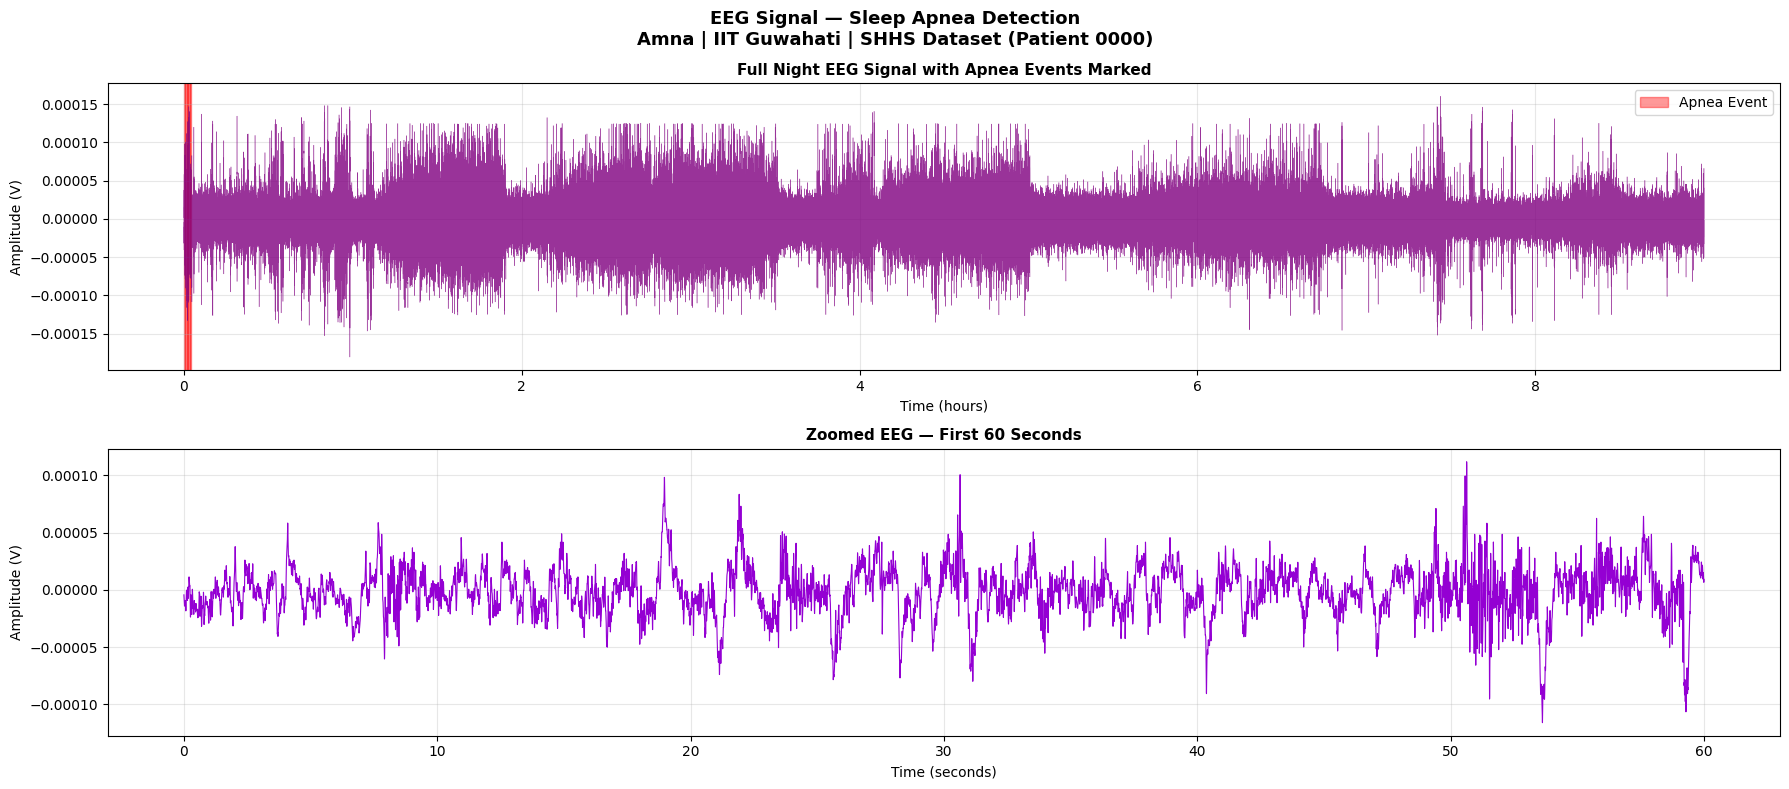

Plot saved


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8))
fig.suptitle("EEG Signal — Sleep Apnea Detection\nAmna | IIT Guwahati | SHHS Dataset (Patient 0000)",
             fontsize=13, fontweight='bold')

# --- Plot 1: Full night EEG with apnea markers ---
ax1 = axes[0]
time_hours = times / 3600
ax1.plot(time_hours, eeg_data, color='purple', linewidth=0.3, alpha=0.8)
ax1.set_title("Full Night EEG Signal with Apnea Events Marked", fontsize=11, fontweight='bold')
ax1.set_xlabel("Time (hours)")
ax1.set_ylabel("Amplitude (V)")
ax1.grid(True, alpha=0.3)

first_label = True
for i, label in enumerate(window_labels):
    if label == 1:
        start = (i * 30) / 3600
        end = ((i + 1) * 30) / 3600
        ax1.axvspan(start, end, color='red', alpha=0.4,
                    label='Apnea Event' if first_label else "")
        first_label = False
ax1.legend(loc='upper right')

# --- Plot 2: Zoomed EEG first 60 seconds ---
ax2 = axes[1]
zoom_samples = int(60 * sfreq)
ax2.plot(times[:zoom_samples], eeg_data[:zoom_samples],
         color='darkviolet', linewidth=0.8)
ax2.set_title("Zoomed EEG — First 60 Seconds", fontsize=11, fontweight='bold')
ax2.set_xlabel("Time (seconds)")
ax2.set_ylabel("Amplitude (V)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/drive/MyDrive/shhs-data/eeg_exploration_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")